In [ ]:
#data understanding and preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#load titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


#firs few records
print(df.head())

#number of rows and coloumns
print("shape:",df.shape)

#column names
print("\nColumns:")
print(df.columns.tolist())

#data types
print("\nData Types:")
print(df.dtypes)

#summary statistics
print("\nStatistical Summary:")
print(df.describe())

#categorical columns
print("/nCategorical Columns:")
print(df.select_dtypes(include='object').columns.tolist())

#numerical columns
print("\nNumerical Columns:")
print(df.select_dtypes(include=['int64','float64']).columns.tolist())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
sh

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
             missing Count  missing Percentage
PassengerId              0            0.000000
Survived                 0            0.000000
Pclass                   0            0.000000
Name                     0            0.000000
Sex                      0            0.000000
Age                    177           19.865320
SibSp                    0            0.000000
Parch                    0            0.000000
Ticket                   0            0.000000
Fare                     0            0.000000
Cabin                  687           77.104377
Embarked                 2            0.224467


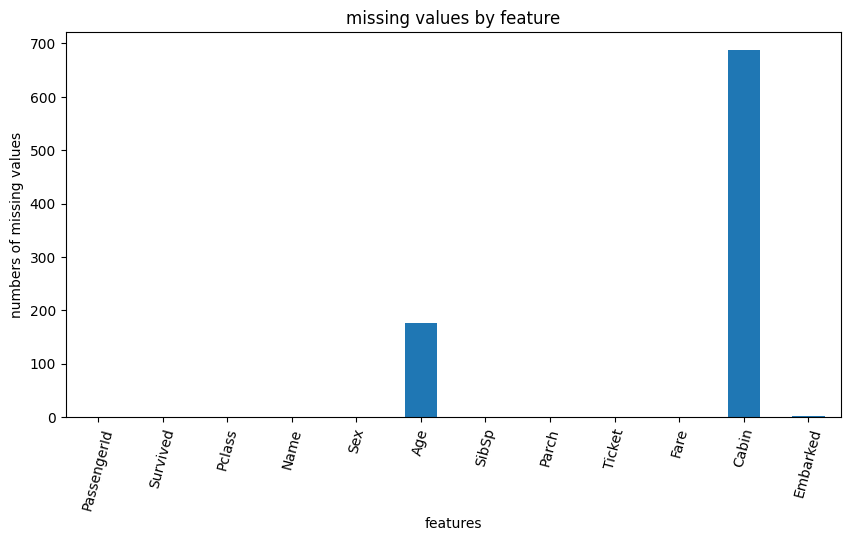

Duplicate rows: 0


In [ ]:
#code for missing values
missing = df.isnull().sum()
print(missing)

missing_percentage = (df.isnull().sum()/ len(df))*100

missing_table = pd.DataFrame({
    "missing Count": missing,
    "missing Percentage": missing_percentage
})

print(missing_table)

plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar')
plt.title("missing values by feature")
plt.xlabel("features")
plt.ylabel("numbers of missing values")
plt.xticks(rotation=75)
plt.show()

print("Duplicate rows:",df.duplicated().sum())


In [ ]:
#mean and median
df_mean = df.copy()

mean_age = df_mean['Age'].mean()
df_mean['Age']= df_mean['Age'].fillna(mean_age)

print("Remaning missing Age values:", df_mean['Age'].isnull().sum())

#replace missing values by median
df_median = df.copy()

median_age = df_median['Age'].median()

df_median['Age'] = df_median['Age'].fillna(median_age)

print("Remaining missing values:", df_median['Age'].isnull().sum())

print("mean Age:", df['Age'].mean())
print("median Age:", df['Age'].median())



#replace missing values by mode - categorical data
df_mode = df.copy()

mode_embarked = df_mode['Embarked'].mode()[0]

df_mode['Embarked'] = df_mode['Embarked'].fillna(mode_embarked)

print("Remaning missing Embarked values:", df_mode['Embarked'].isnull( ).sum())



Remaning missing Age values: 0
Remaining missing values: 0
mean Age: 29.69911764705882
median Age: 28.0
Remaning missing Embarked values: 0


In [ ]:
#encoding - one-hot
print(df[['Sex','Embarked']].head(10))
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

encoded = encoder.fit_transform(df[['Sex','Embarked']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Sex','Embarked'])
)

print(encoded_df.head())

#encoding -label 1
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Survived_encoded'] = le.fit_transform(df['Survived'])
print(df[['Survived','Survived_encoded']].head())
display(df[['Survived','Survived_encoded']].head())



      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan
0         0.0       1.0         0.0         0.0         1.0           0.0
1         1.0       0.0         1.0         0.0         0.0           0.0
2         1.0       0.0         0.0         0.0         1.0           0.0
3         1.0       0.0         0.0         0.0         1.0           0.0
4         0.0       1.0         0.0         0.0         1.0           0.0
   Survived  Survived_encoded
0         0                 0
1         1                 1
2         1                 1
3         1                 1
4         0                 0


,Survived,Survived_encoded
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


In [ ]:
#min-max Scaling
features = df[['Age','Fare']].dropna()

print(features.describe())
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
Scaled_minmax = minmax.fit_transform(features)

minmax_df = pd.DataFrame(
    Scaled_minmax,
    columns=['Age','Fare']
    )
display(minmax_df.head())



              Age        Fare
count  714.000000  714.000000
mean    29.699118   34.694514
std     14.526497   52.918930
min      0.420000    0.000000
25%     20.125000    8.050000
50%     28.000000   15.741700
75%     38.000000   33.375000
max     80.000000  512.329200


,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [ ]:

#Standardisation
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()

Scaled_standard = standard.fit_transform(features)

standard_df = pd.DataFrame(
    Scaled_standard,
    columns=['Age','Fare']
)
print (standard_df.head())

        Age      Fare
0 -0.530377 -0.518978
1  0.571831  0.691897
2 -0.254825 -0.506214
3  0.365167  0.348049
4  0.365167 -0.503850
